<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.1: Neural Networks</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Introduction to Neural Networks**

Like many innovations in the technology space, many of it owes their inspiration to biology. For example, the Artificial Neurons used to build Neural Networks are inspired by the human biological neuron within our brains.

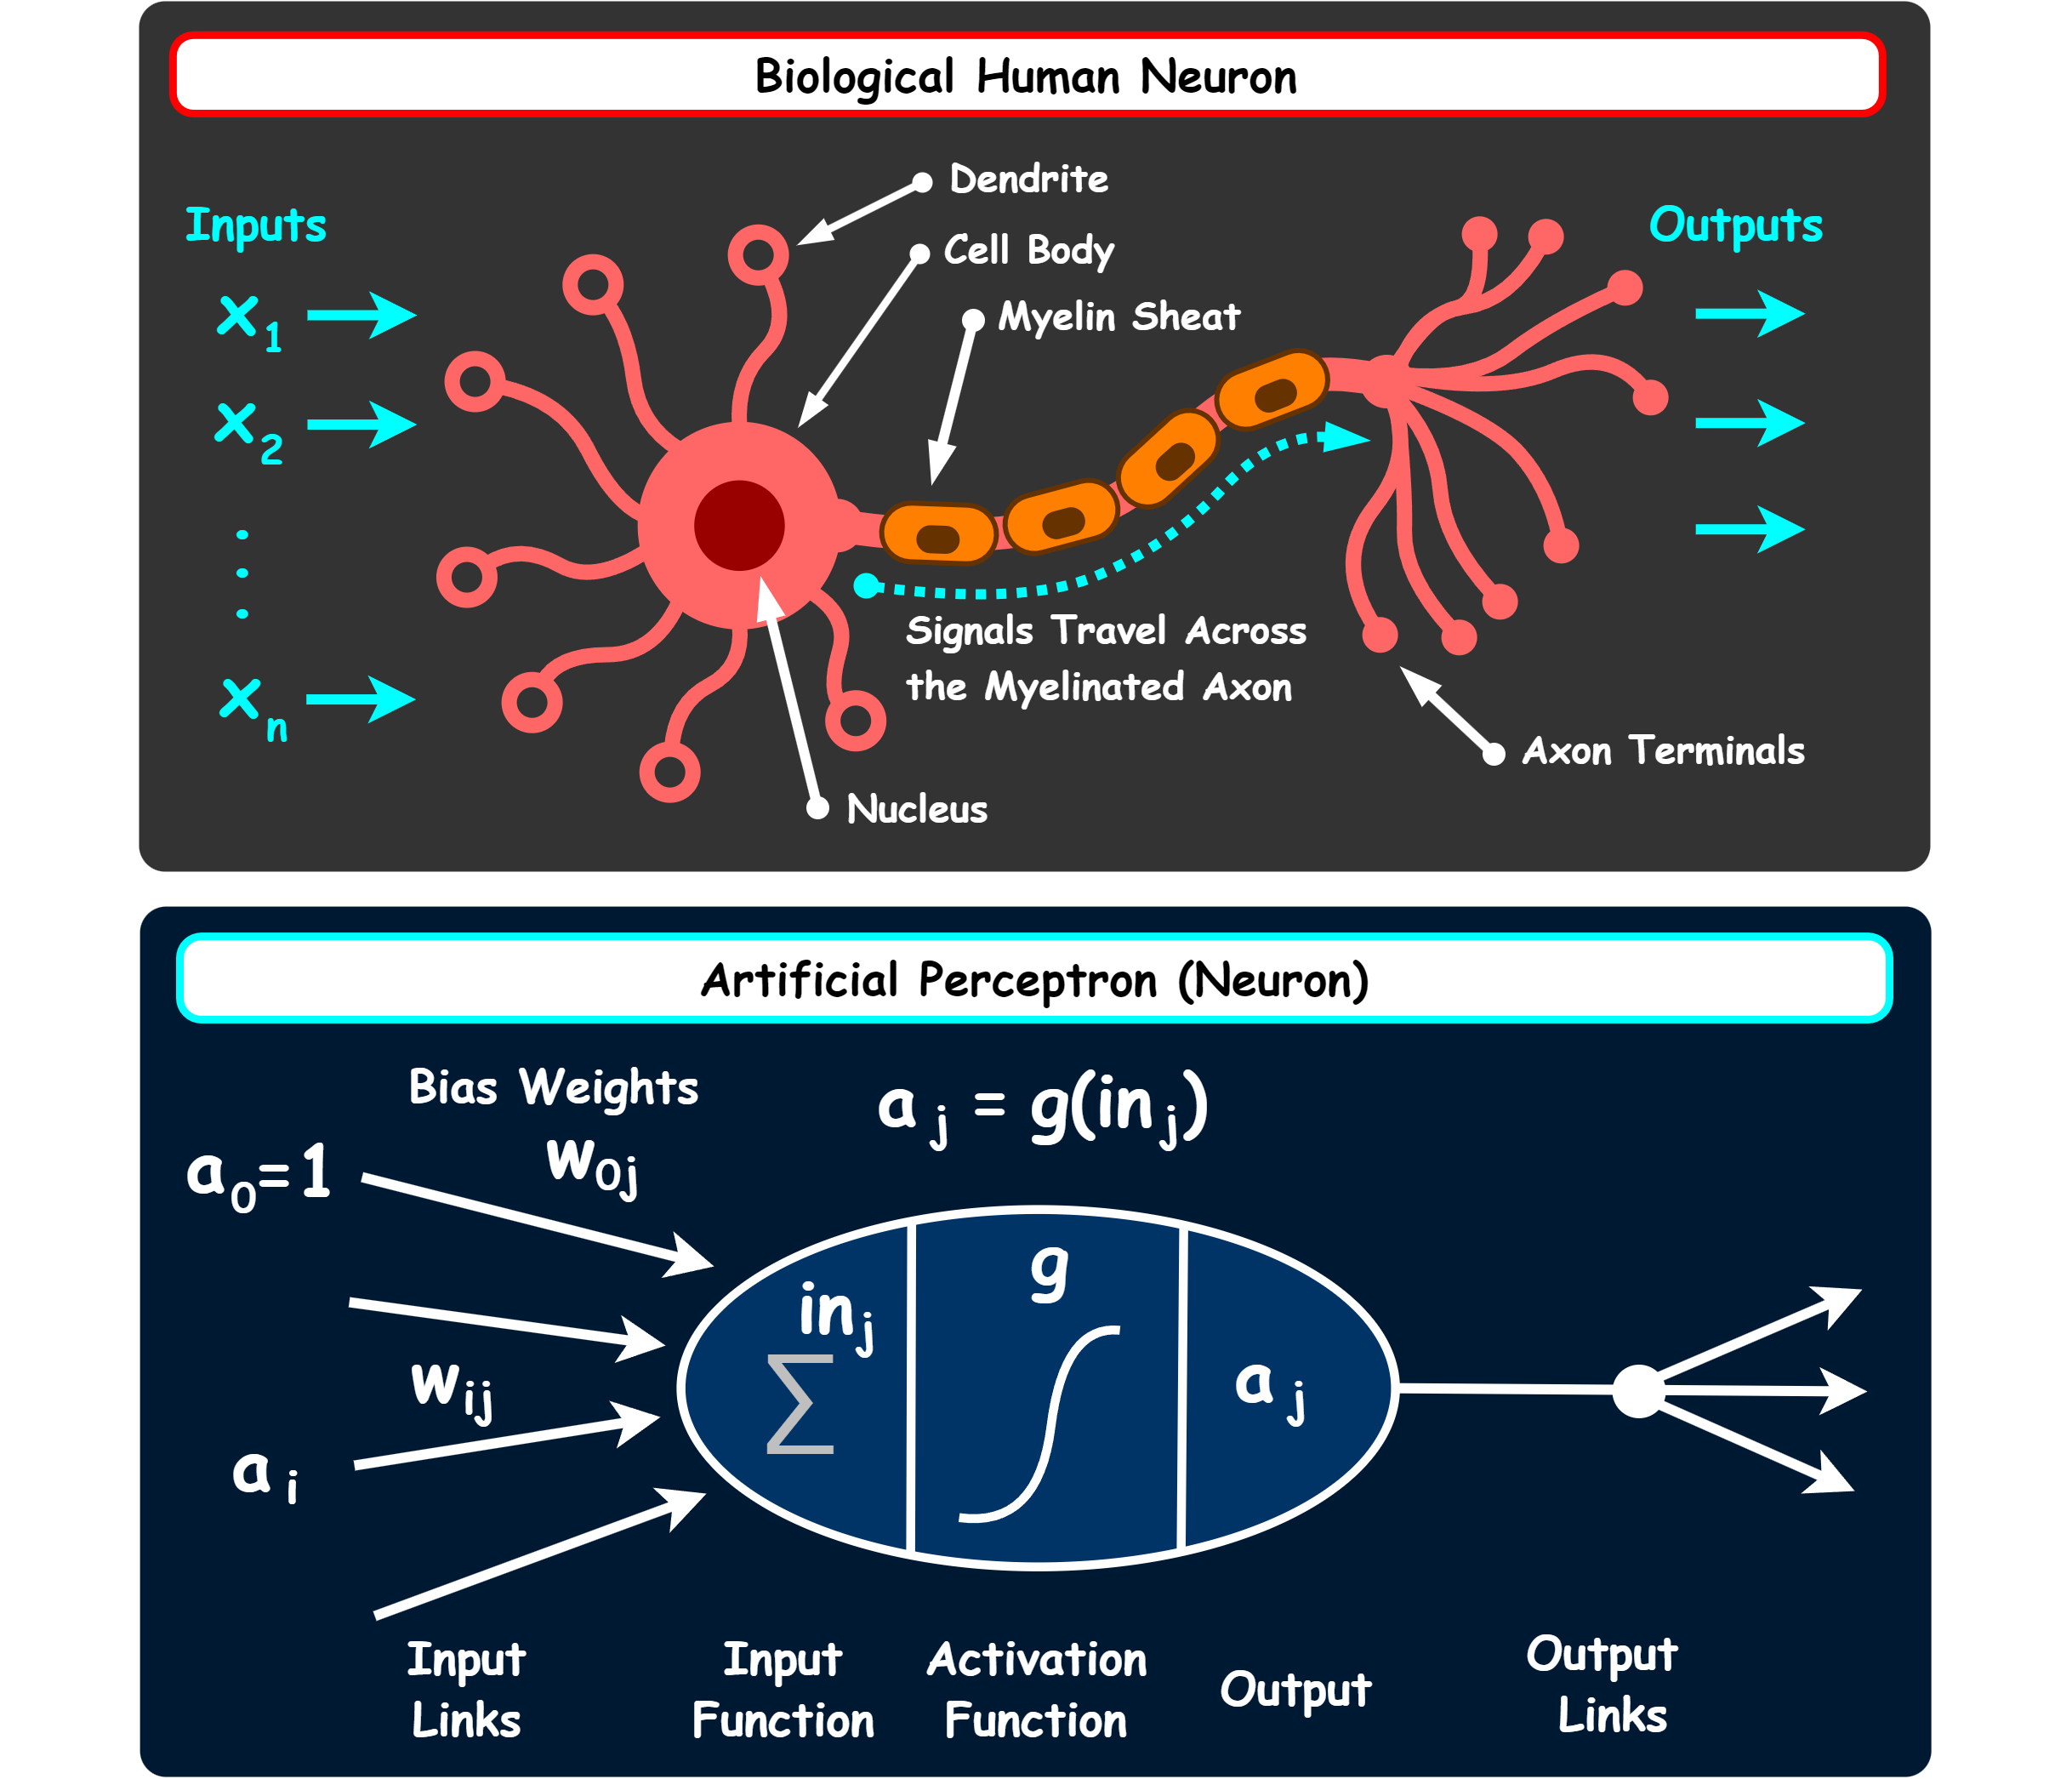

<br>

### **Feed-Forward Neural Networks**

A feed-forward network's goal is to approximate some ideal function $f^*$. In a classification task, for instance, the ideal function $f^*(x)$ maps an input $x$ to a category $y$. The network achieves this by defining a mapping $y = f(x;\theta)$, where $\theta$ are the learnable parameters (weights and biases) that get optimized during training to produce the **best possible approximation** of $f^*$.

These models are called *feed-forward* because information flows in **one direction only**, starting from the input $x$, passing through a series of intermediate computations, and finally arriving at the output $y$. Unlike other architectures, there are no loops or feedback connections; data always moves strictly forward through the network.

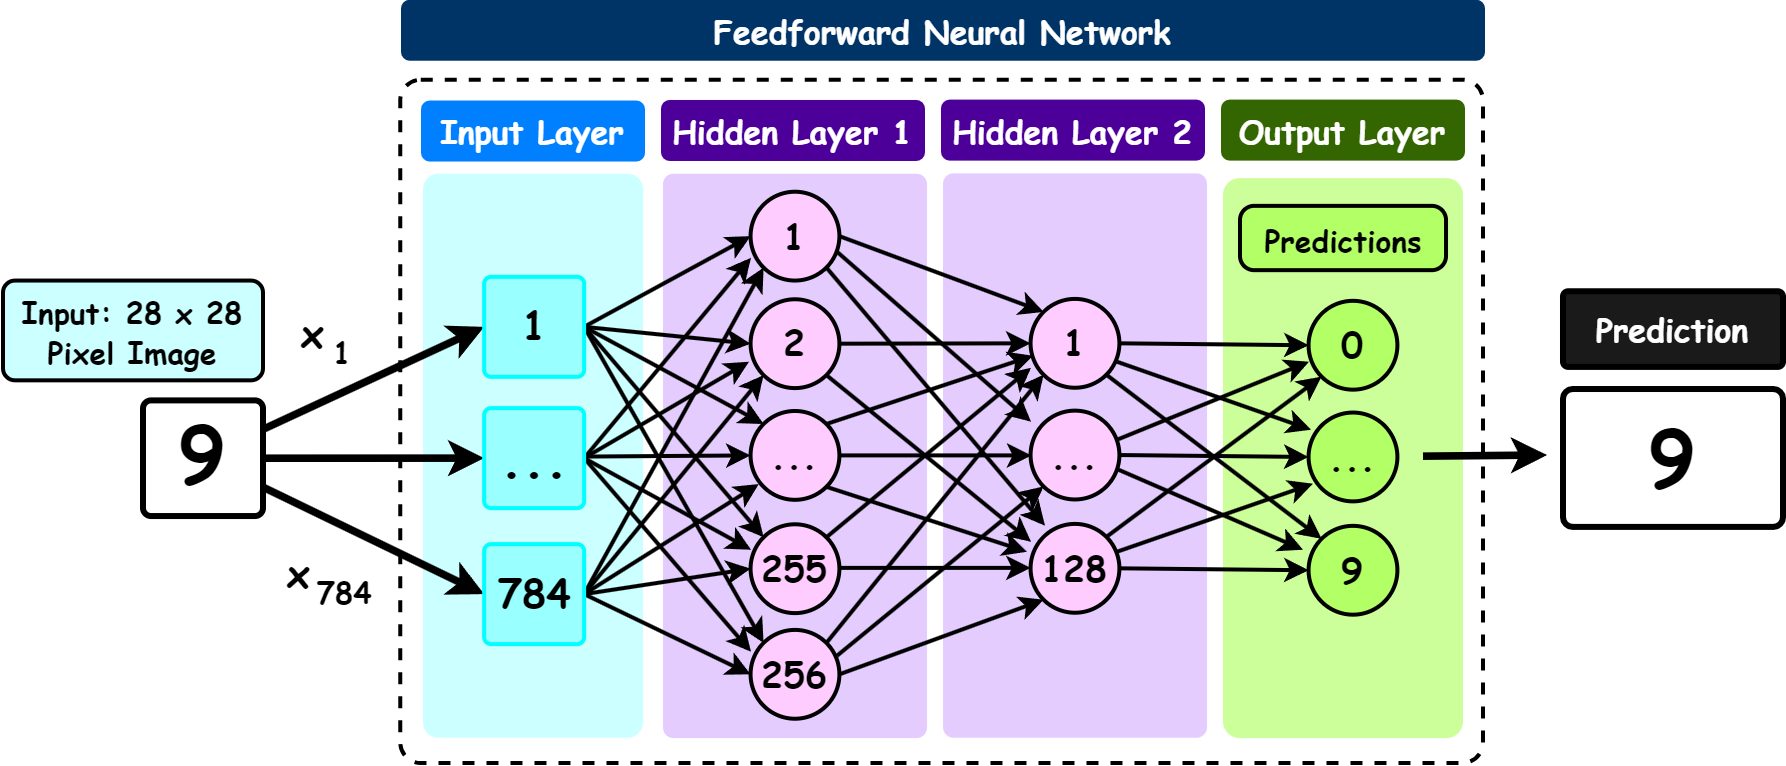

<br>

### **Activation Function**

Activation functions are mathematical functions applied to the output of each neuron in a neural network. They determine whether a neuron should "fire" or not — essentially controlling how much signal gets passed forward through the network.

Without activation functions, no matter how many layers you stack, the network would only be capable of linear transformations, limiting it to solving simple linear problems. Activation functions introduce **non-linearity**, allowing the network to learn complex patterns in data.

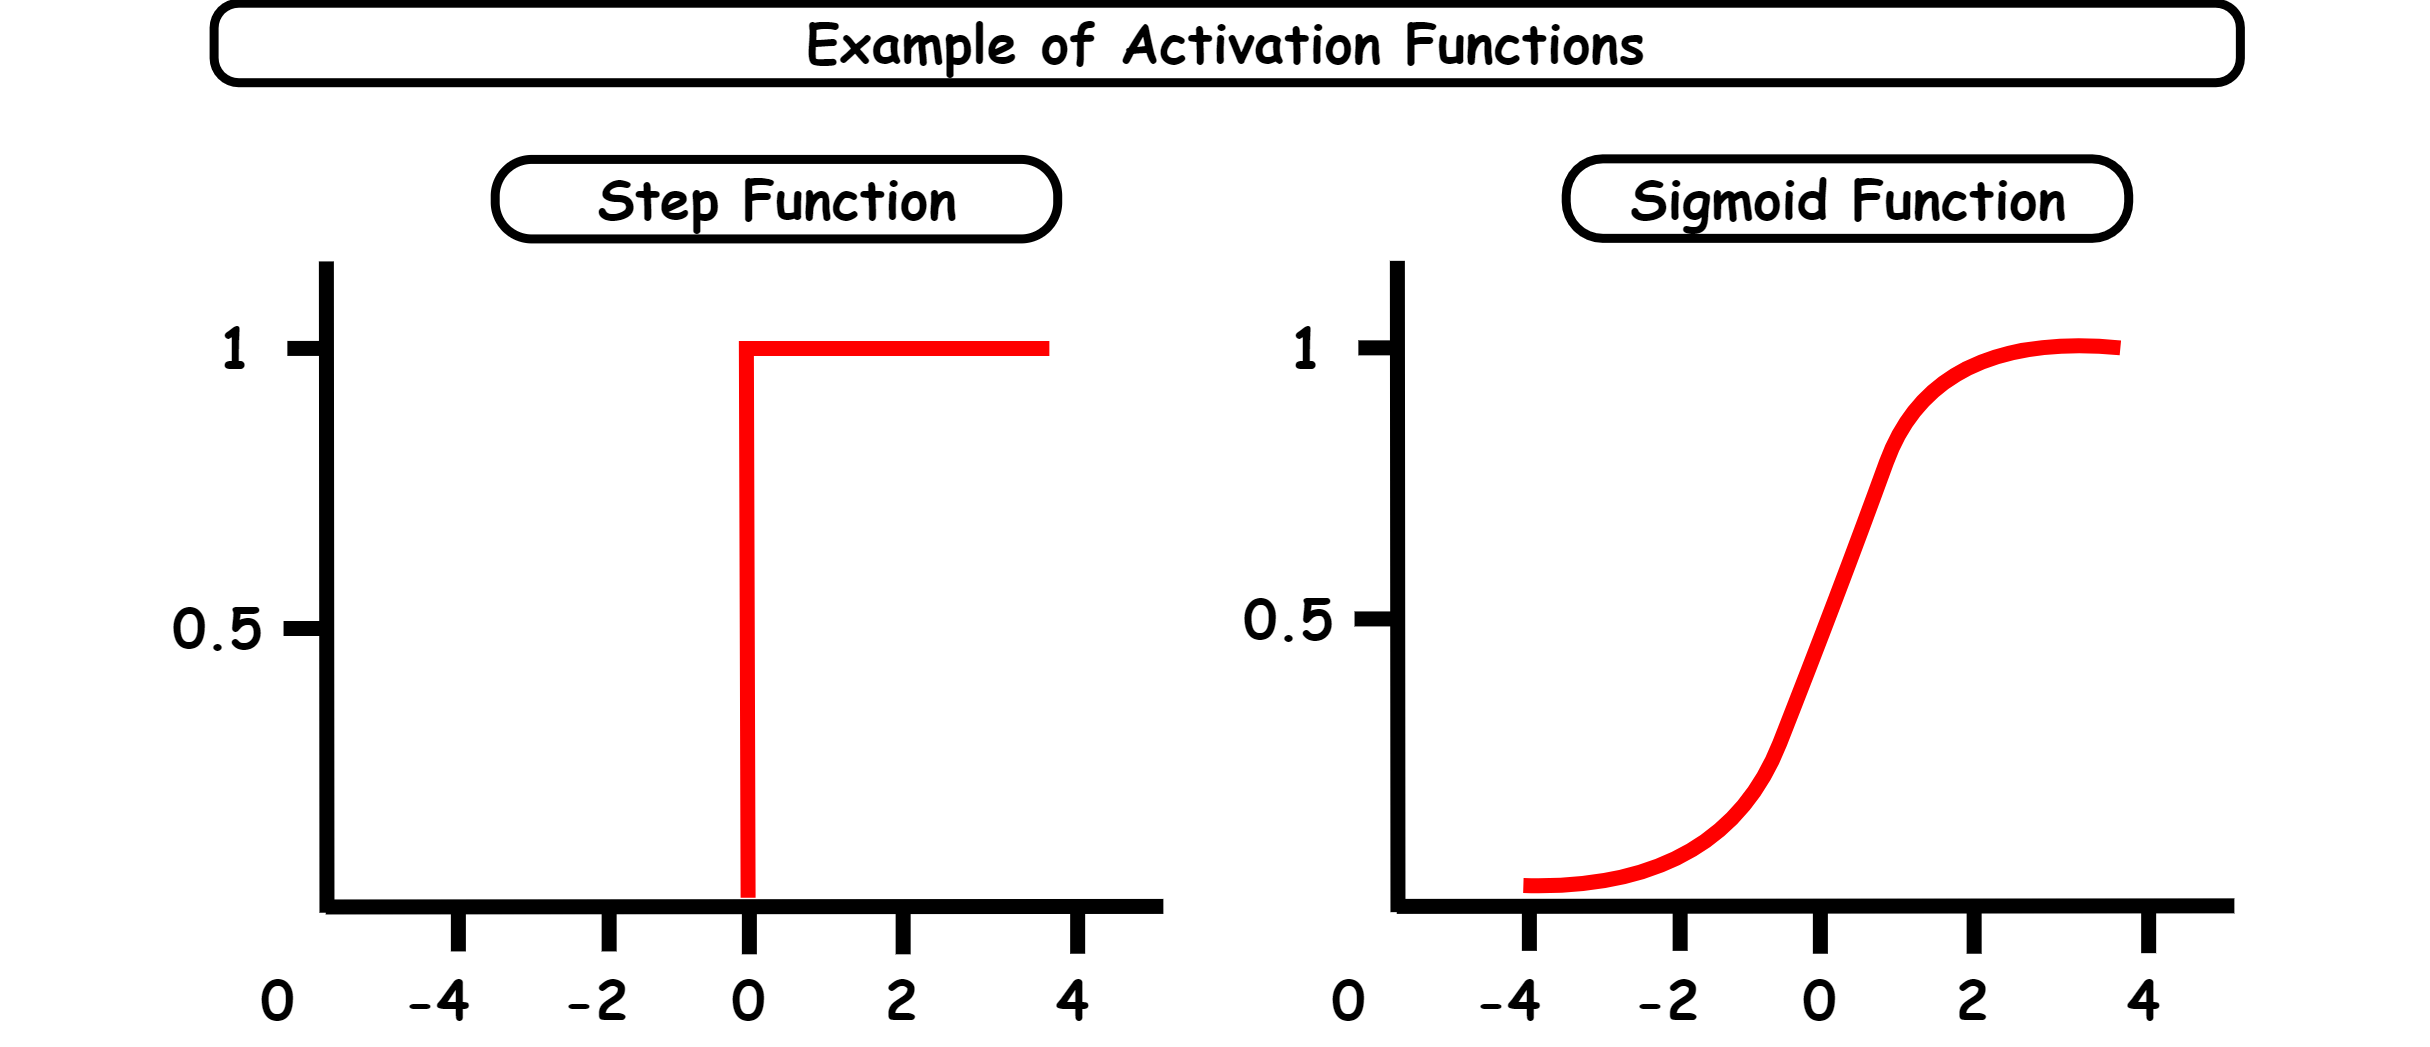

Some common activation functions include:

- **Sigmoid** — squashes output between $0$ and $1$, useful for probability-based outputs
- **ReLU (Rectified Linear Unit)** — outputs $0$ for negative values, and the value itself for positive values. It is the most widely used activation function today
- **Tanh** — similar to Sigmoid but squashes output between $-1$ and $1$

<br>

### **Single Layer Perceptron (Simplest Feedforward Neural Network)**

The simplest form of a feedforward neural network is the **single layer perceptron**. In this model, a set of inputs are each multiplied by their corresponding weights and summed together to produce a single weighted sum. This result is then passed through a threshold function, if the sum exceeds a set threshold (typically zero), the network outputs $1$; otherwise, it outputs $-1$.

Despite its simplicity, the single layer perceptron is a foundational model in deep learning and serves as an important building block for understanding feedforward networks. It is most commonly applied to **binary classification tasks**, where the goal is to separate data into one of two categories.

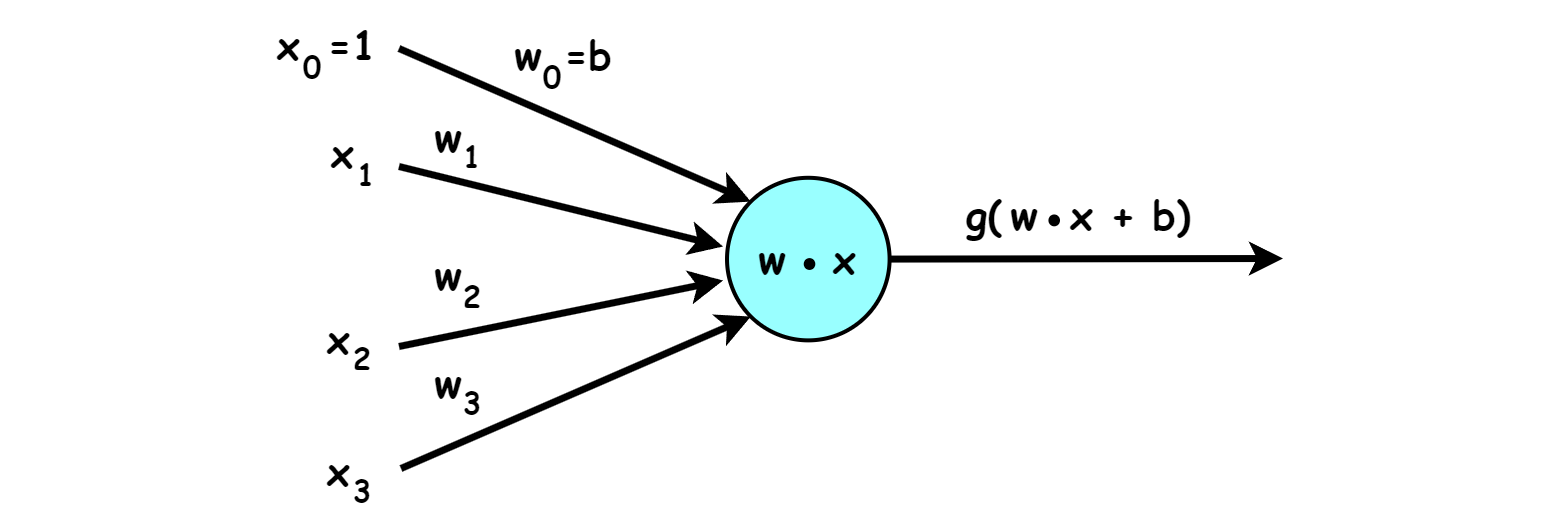

A feedforward neural network with even a single hidden layer containing a sufficient number of neurons can theoretically **represent any continuous function**, given enough neurons and training data. This is known as the *universal approximation theorem*.

Each neuron in the network follows the same fundamental computation:

1. Takes a **weighted sum** of its inputs
2. Adds a **bias term**
3. Applies an **activation function** to introduce non-linearity into the model

---

### **Bias Term & Updated Score**

The score formula can include a **bias term** $b$, which acts as a baseline offset independent of any feature. Think of bias like a default assumption, even before looking at any features, the model starts with a prior lean in one direction. This lets the model shift its decision boundary.

$$Z = \mathbf{w} \cdot \varphi(x) + b = \sum_{j=1}^{k} w_j \varphi_j(x) + b$$

**Step by step with our example** (using $b = 0.1$):

$$Z = (2.5 \times 3) + (-5.0 \times 2) + (-1.2 \times 1) + (0.5 \times 3) + (2.0 \times 0) + (0.7 \times 4.19) + 0.1$$
$$= 7.5 - 10.0 - 1.2 + 1.5 + 0 + 2.933 + 0.1$$
$$= 0.833$$

<br>

### **From Score to Probability — The Sigmoid Function**

The raw score $Z$ is not a probability, it can be any real number. To convert it into something meaningful (a value between 0 and 1), we pass it through the **sigmoid** (logistic) function. Think of sigmoid as a "squasher" — no matter how extreme the score is, it always returns a tidy number between 0 and 1:

$$y = \sigma(Z) = \frac{1}{1 + e^{-z}}$$

This squashes any score into the range $[0, 1]$, which we can interpret as a
probability. The full logistic regression model is then:

$$P(y = 1) = \sigma(\mathbf{w} \cdot \varphi(x) + b) = \frac{1}{1 + e^{-(\mathbf{w} \cdot \varphi(x) + b)}}$$

And since there are only two outcomes:

$$P(y = 0) = 1 - P(y = 1)$$

#### **Example of Applying sigmoid to our score:**

$$P(y = 1) = \frac{1}{1 + e^{-(0.833)}} \approx 0.7$$

$$P(y = 0) = 1 - 0.7 = 0.3$$

The model predicts a **70% chance** the review is positive, and a **30% chance** it is negative.

<br>

### **Loss Function and Cross-Entropy**

**Goal:** find the parameters $\mathbf{w}$ and $b$ that maximise the probability of predicting the correct label $y$ given input $x$. In short, the loss function is how the model measures its own mistakes — a higher loss means the model's prediction was far off from the truth.

With only two possible outcomes (0 or 1), the probability of the correct label from our classifier can be written compactly as:

$$p(y|x) = \hat{y}^{y}(1 - \hat{y})^{1-y}$$

Where $\hat{y} = \sigma(\mathbf{w} \cdot \varphi(x) + b)$ is the model's output. Notice that this is just the **Bernoulli distribution**, when $y = 1$ it simplifies to $\hat{y}$, and when $y = 0$ it simplifies to $1 - \hat{y}$.

#### **Taking the log**

We maximise the log probability instead — the log is monotonic, so whatever parameters maximise $\log p(y|x)$ will also maximise $p(y|x)$. Using log also turns multiplications into additions, making the math far more tractable. This is mathematically easier to work with:

$$\log p(y|x) = \log\left[\hat{y}^{y}(1-\hat{y})^{1-y}\right] = y\log\hat{y} + (1-y)\log(1-\hat{y})$$

#### **Turning it into a loss**

We flip the sign to convert from something to *maximise* into something to *minimise*. This gives us the **cross-entropy loss**:

$$L_{CE}(\hat{y}, y) = -\log p(y|x) = -\left[y\log\hat{y} + (1-y)\log(1-\hat{y})\right]$$

#### **Partial derivatives** (used during gradient descent):

$$\frac{\partial L_{CE}(\hat{y}, y)}{\partial w_j} = [\sigma(\mathbf{w} \cdot \varphi(x) + b) - y]\,\varphi_j(x)$$

$$\frac{\partial L_{CE}(\hat{y}, y)}{\partial b} = \sigma(\mathbf{w} \cdot \varphi(x) + b) - y$$

---

<br>

### **From Logistic Regression to a Neural Classifier**

#### **Logistic Regression as a graph**

We can draw logistic regression visually: each feature $\varphi(x)_j$ is an input node, all connected by weights $\mathbf{w}$ to a single output node that computes the score, which is then passed through sigmoid. This graph view makes it easy to see how information flows from raw features all the way to a final prediction:

$$\text{score} = \mathbf{w} \cdot \varphi(x) \qquad y = \sigma(\text{score}) = \frac{1}{1 + e^{-\text{score}}}$$

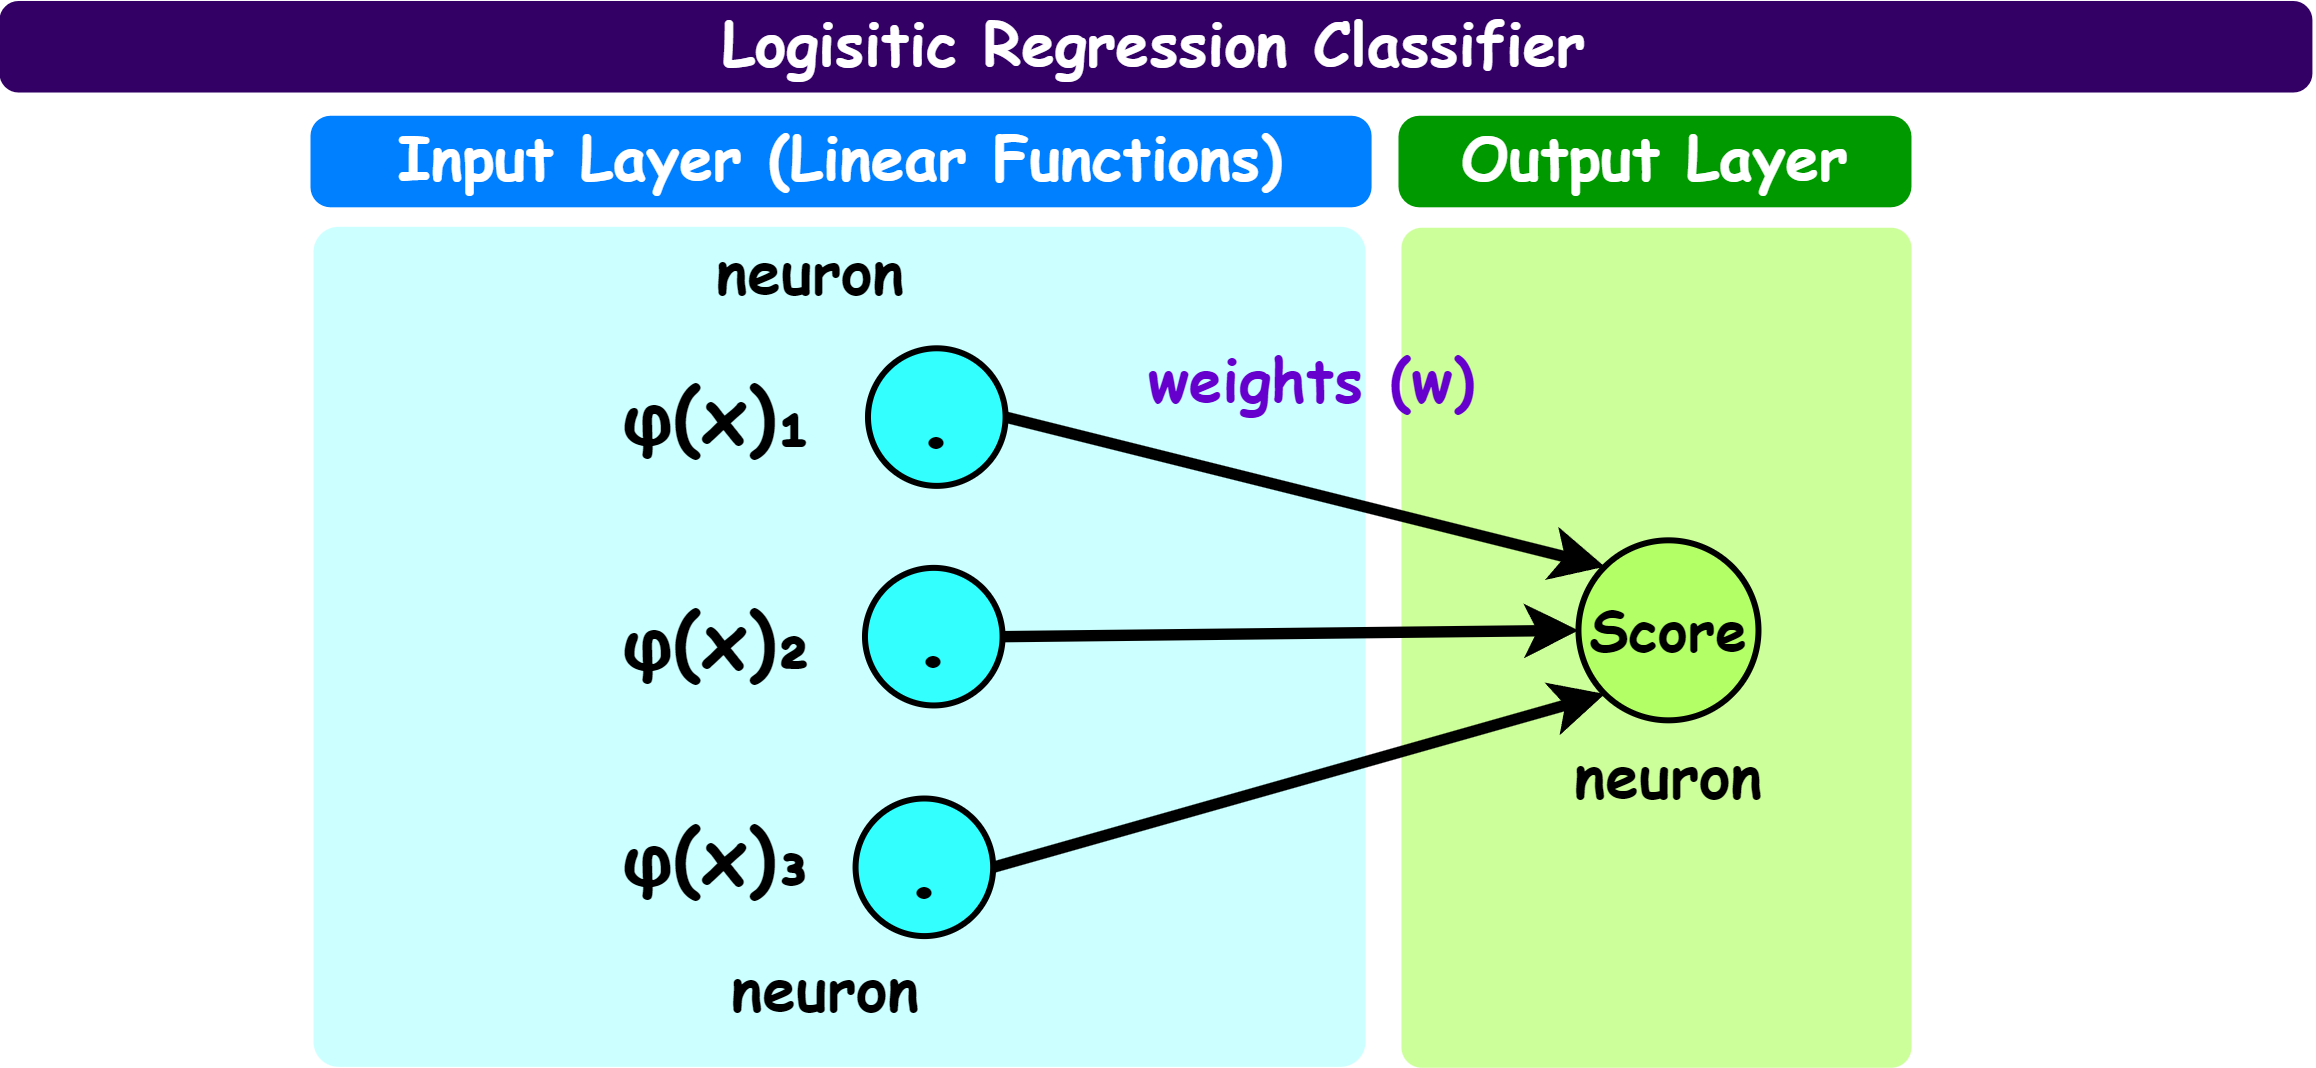

<br>

#### **Adding a hidden layer: Neural Binary Classifier**

A neural network extends this by inserting one or more **hidden layers** between the inputs and the output. The hidden layer is where the network learns abstract, intermediate patterns that raw features alone cannot capture. Each hidden unit $h_j$ applies its own set of weights $\mathbf{v}_j$ and a sigmoid activation:

$$h_j = \sigma(\mathbf{v}_j \cdot \varphi(x)) \qquad \sigma(z) = (1 + e^{-z})^{-1}$$

The output score is then computed from the hidden layer vector $\mathbf{h}$:

$$\text{score} = \mathbf{w} \cdot \mathbf{h} \qquad y = \sigma(\text{score}) = \frac{1}{1 + e^{-\text{score}}}$$

The key difference: instead of computing a score directly from hand-crafted features, the network **learns its own intermediate representations** in the hidden layer. The weights $\mathbf{V}$ (input → hidden) and $\mathbf{w}$ (hidden → output) are all learned from data.

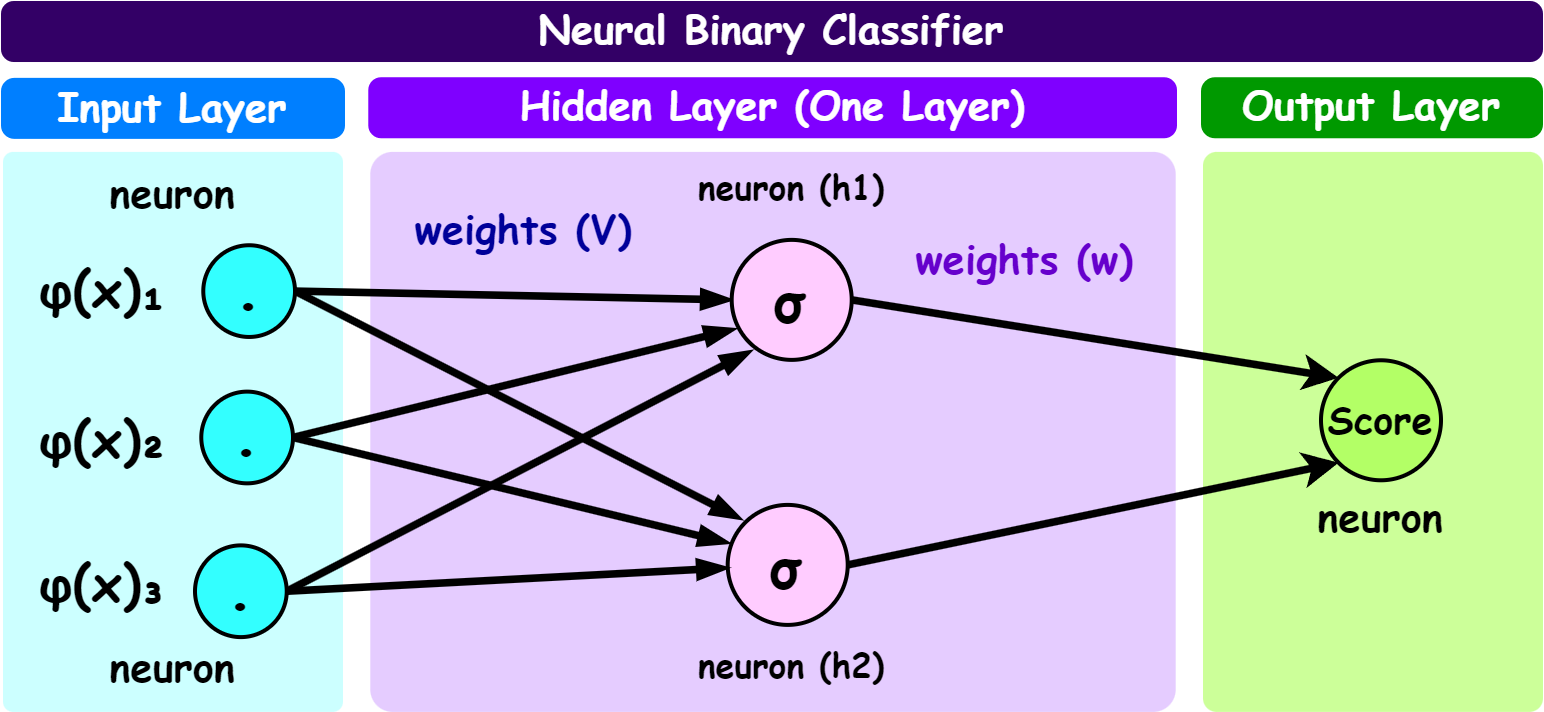

<br>

#### **Diagram Illustrating a Multi-Layer Neural Newtwork with Weights and Bias**

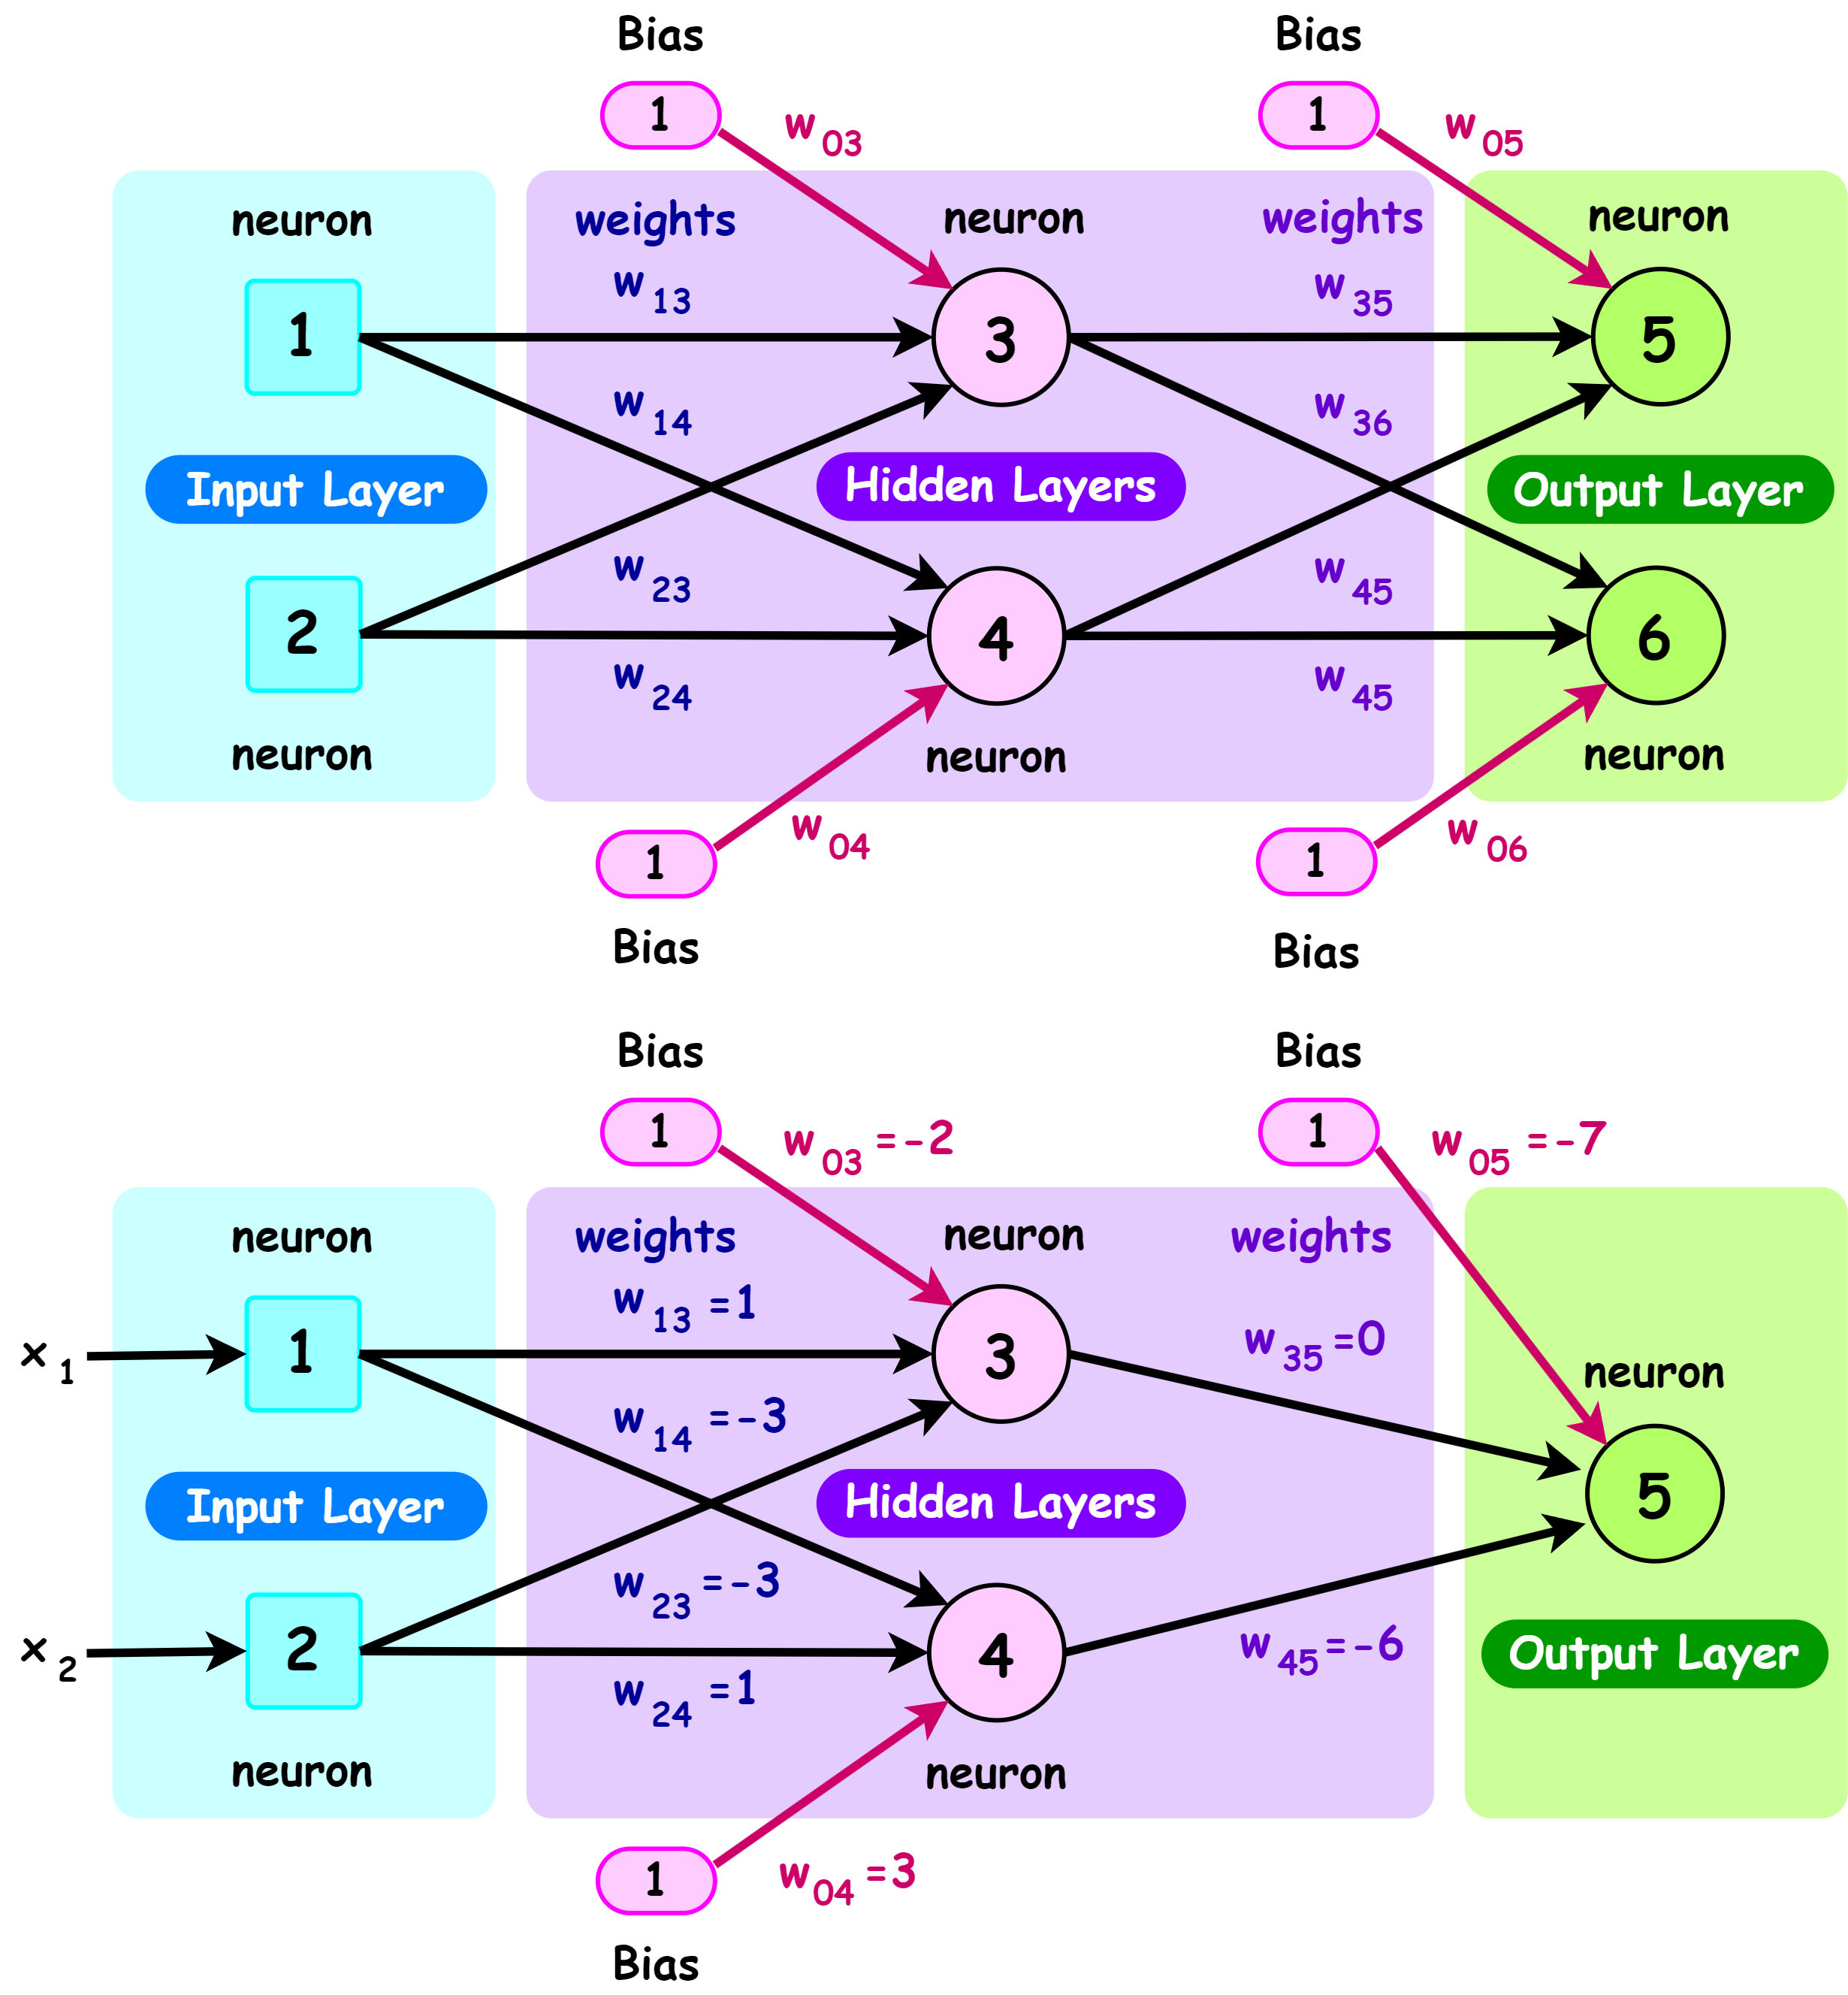

<br>

### **Extending to Multiple Classes — Softmax**

#### **Binary case** ($K = 2$)

When there are only two classes, the output is a single scalar $z$ passed through sigmoid. This works because with only two outcomes, knowing the probability of one immediately tells you the probability of the other:

$$y_1 = \sigma(\mathbf{z}) = \frac{1}{1 + e^{-z}} \qquad y_2 = 1 - y_1$$

#### **Multiclass case** ($K \geq 2$)

When there are $K$ classes, the model outputs a **vector** of $K$ scores $\vec{z}$. Softmax is the generalisation of sigmoid to multiple classes,  instead of splitting probability between two outcomes, it spreads it across all $K$ classes at once. We convert this into a probability distribution using the **softmax** function:

$$y_k = \text{softmax}(\vec{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Softmax ensures all output values are positive and sum to 1, making them valid probabilities. Note that for $K = 2$, softmax reduces to the sigmoid function.

---